# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Miriam Wepiya Gale]
**Student ID:** [46582028]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [103]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

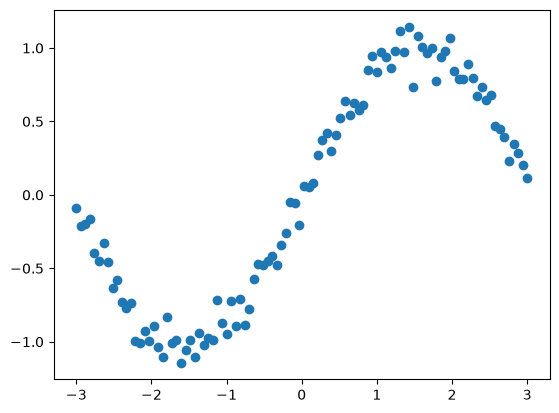

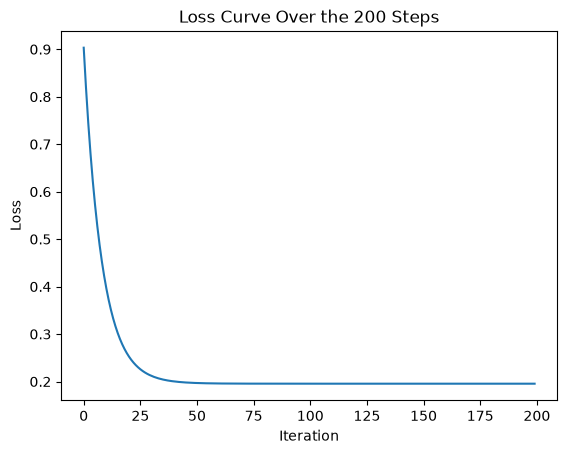

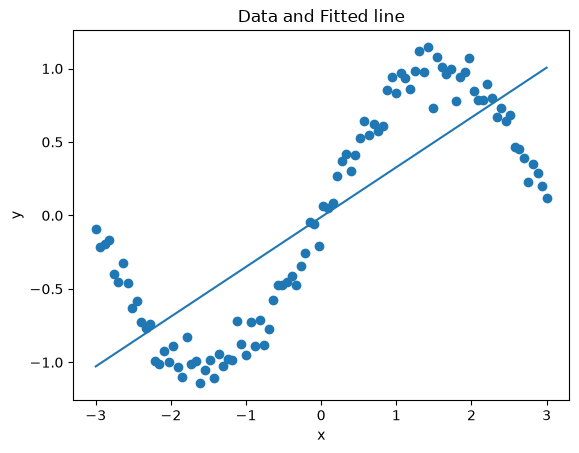

In [104]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) +  np.random.normal(0, 0.1, 100)
plt.scatter(x,y)
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.normal(0, 0.1)
b = np.random.normal(0,0.1)

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.01
losses = []
for i in range(200):
  y_hat = w * x + b
  loss  = np.mean((y_hat - y) ** 2)
  dw    = np.mean(2 * (y_hat - y) * x)
  db    = np.mean(2 * (y_hat - y))                # dLoss/db
  w    -= lr * dw
  b    -= lr * db
  losses.append(loss)
y_hat = w * x + b
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Curve Over the 200 Steps")
plt.show()
#             (b) the data with the fitted line on top.

plt.scatter(x,y)
plt.plot(x, y_hat)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data and Fitted line")
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** 
*1  
$$
Loss = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2
$$


The prediction is given by

$$
\hat{y}_i = wx_i + b
$$


Substituting \(\hat{y}_i\) into the loss function gives: 

$$
Loss = \frac{1}{n}\sum_{i=1}^{n}(wx_i + b - y_i)^2
$$

Taking the derivative of the loss with respect to \(w\):

$$
\frac{dLoss}{dw}
=
\frac{1}{n}
\sum_{i=1}^{n}
2(wx_i+b-y_i)x_i
$$


Since

$$
\hat{y}_i = wx_i + b,
$$

the derivative can be written as

$$
\frac{dLoss}{dw}
=
\frac{2}{n}
\sum_{i=1}^{n}
(\hat{y}_i-y_i)x_i
$$


*2
The model is **underfitting** because it is too simple to learn the complex patterns in the data. A single neuron uses the equation

$$
\hat{y}_i = wx_i + b
$$

which can only produce a straight line. Since a sine wave is curved, the model cannot fit it well, so it makes poor predictions even after many training iterations. No matter how long the model is trained, it cannot accurately fit a sine wave because changing the values of \(w\) and \(b\) does not change the model from a straight line into a curved function.


### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

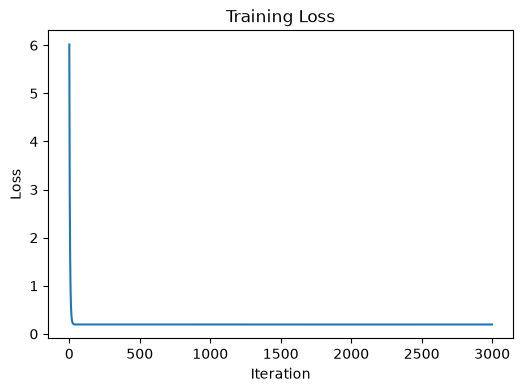

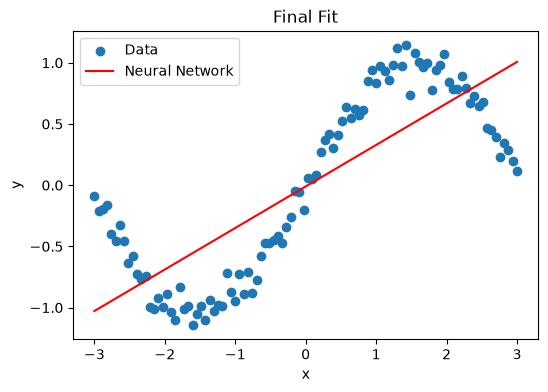

In [105]:
# TODO: Initialise parameters
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.01
losses = []

# Train the network
for i in range(3000):

    # Forward pass
    z1 = x @ W1 + b1
    h = z1
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)

    # Save loss
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Neural Network")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Final Fit")
plt.legend()
plt.show()

# Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** 

*1
Without the activation function, tanh, the hidden layer is just  
$$
h = xW1 + b1
$$

The output layer is given by: $$ y = hW2 + b2 $$

Substituting the expression for the hidden layer into the output layer:
$$
y = (xW1 + b1)W2 + b2 
$$

$$
y = xW1W2 + b1W2 + b2
$$

$$
y = x(W1W2) + (b1W2 + b2)
$$

Since 
$$
W1W2
$$ 
can be treated as a new weight matrix and 
$$
(b1W1+b2) 
$$
as the new bias, the equation can be rewritten as:
$$
y = xW + b
$$
where $$ W = W1W2$$ and $$b= b1W2+b2$$. Therefore, stacking multiple linear layers is the same as a single layer. Without the tanh activation function, the network or model cannot learn nonlinear relationships or patterns, so it does not perform better than the single neuron in Part 1.1


* 2
The hidder layer contains 8 neurons, each of the neurons having its own weights and bias.
Each neuron learns a different non linear feature of the input after it has been applied the tanh activation function.

* 3
Backpropagation is the process of retracing the network from the loss to calculate how each parameter contributed to error, so the weight and biases can be updated to improve the model.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

c:\Users\HP\lab-3\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\HP\AppData\Local\Temp\ipykernel_16916\2902498625.py:9: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
C:\Users\HP\AppData\Local\Temp\ipykernel_16916\2902498625.py:20: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\HP\AppData\Local\Temp\ipykernel_16916\2902498625.py:21: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
c:\Users\HP\lab-3\.venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


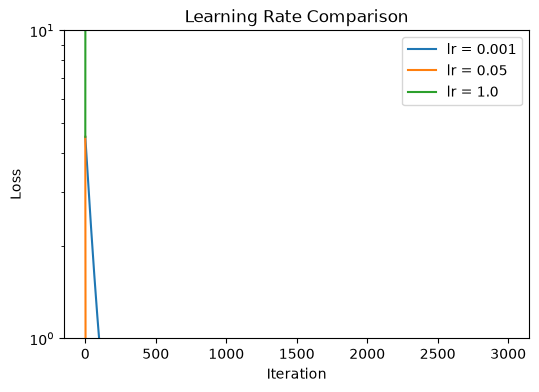

In [106]:
# TODO: Wrap your Part 1.2 training loop in a function
def train_toy(lr, steps=3000):
  global W1, b1, W2, b2
  losses = []
  for i in range(steps):
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)
    
    # Save loss
    losses.append(loss)
    
    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)
    
    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
  return losses
#   that returns the list of losses.

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

np.random.seed(42)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

loss1 = train_toy(0.001)


np.random.seed(42)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

loss2 = train_toy(0.05)

np.random.seed(42)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

loss3 = train_toy(1.0)
# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

plt.figure(figsize=(6,4))

plt.plot(loss1, label="lr = 0.001")
plt.plot(loss2, label="lr = 0.05")
plt.plot(loss3, label="lr = 1.0")

plt.yscale("log")          # Log scale on the y-axis
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()

plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** 
The curve for lr = 0.001 shows slow but steady learning because the weight updates are very small. The curve for lr = 0.05 decreases much faster and converges quickly, making it the best learning rate among the three. The curve for lr = 1.0 becomes unstable because the updates are too large. Instead of moving gradually toward the minimum loss, the model overshoots it on each update, causing the loss to oscillate or even explode rather than learn faster.


---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [107]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity_df = pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
obesity_df["Gender"] = obesity_df["Gender"].map({"Female" : 1, "Male" : 0})

obesity_df["FAVC"] = obesity_df["FAVC"].map({"yes" : 1, "no": 0} )

obesity_df["CAEC"] = obesity_df["CAEC"].map({"no": 0, "Sometimes": 1, "Frequently": 2,  "Always": 3})

obesity_df["SMOKE"] = obesity_df["SMOKE"].map({"yes": 1, "no": 0})


obesity_df["SCC"] = obesity_df["SCC"].map({"yes": 1, "no": 0})

obesity_df["CALC"] = obesity_df["CALC"].map({"no": 0, "Sometimes": 1, "Frequently": 2,  "Always": 3})

obesity_df= pd.get_dummies(obesity_df, columns=["MTRANS"], dtype= int)

obesity_df["family_history_with_overweight"] = obesity_df["family_history_with_overweight"].map({"yes": 1, "no" : 0})



#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
label_encoder = LabelEncoder()
obesity_df["NObeyesdad"] = label_encoder.fit_transform(obesity_df["NObeyesdad"])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity_df.drop("NObeyesdad", axis=1)
y = obesity_df["NObeyesdad"]

X_temp, X_test, y_temp, y_test = train_test_split( X, y,
random_state=42,test_size=0.20,shuffle=True, stratify=y)

X_train, X_val, y_train, y_val = train_test_split( X_temp,y_temp,random_state=42,test_size=0.25,shuffle=True, stratify=y_temp)



# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
standard_scaler = StandardScaler()
standard_scaler.fit(X_train)
X_train_scaled = standard_scaler.transform(X_train)
X_val_scaled = standard_scaler.transform(X_val)
X_test_scaled = standard_scaler.transform(X_test)

#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)
# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 
*1  CrossEntropyLoss requires integer class labels because it expects each sample to belong to exactly one class. It compares the model's predicted probabilities with the correct class index to compute the loss. Using one-hot vectors would not match the expected input format for CrossEntropyLoss.

* 2
Random forests do not depend on feature scaling because they split data based on feature values rather than using gradient-based optimization. Neural networks, however, update their weights using gradients. If features have very different scales, the gradients can become very large or very small, causing unstable or slow learning. This connects to Section 1, where the gradients (such as 
$$
dW
1
$$
	​

  and
  $$

 dW
2
$$) 
depended on the input x. Scaling the features keeps the gradients at a similar magnitude, helping the network train more efficiently and converge faster.

* 3
Setting shuffle=True randomly changes the order of the training samples at the beginning of each epoch. This prevents the model from learning patterns based on the order of the data, reduces bias during training, and usually leads to better generalization and more stable learning.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [108]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()
        self.first_layer = nn.Linear(input_dim, hidden_sizes[0])

        self.second_layer = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.output_layer = nn.Linear(hidden_sizes[1], n_classes)



     
    def forward(self, x):
        x = self.first_layer(x)
        x = self.relu1(x)
        x = self.second_layer(x)
        x = self.relu2(x)
        x = self.output_layer(x)
        return x

input_dim = X_train_tensor.shape[1]
model = FeedForwardNet(input_dim)
model = model.to(DEVICE)
print(model)

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_parameters)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

## first layer count = input_dim * 64 + 64
## Substituting input_dim = 20
## 20* 64+ 64 = 1344
##First layer has 1344 trainable parameters


FeedForwardNet(
  (first_layer): Linear(in_features=20, out_features=64, bias=True)
  (second_layer): Linear(in_features=64, out_features=32, bias=True)
  (relu1): ReLU()
  (relu2): ReLU()
  (output_layer): Linear(in_features=32, out_features=7, bias=True)
)
3655


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** 

* 1
First layer (20 -> 64): 20 * 64 + 64 = 1344

Second layer (64 -> 32): 64 * 32 + 32  = 2080

Output layer(32 -> 7): 32 * 7 + 7 = 231

Total trainable parameters in all layers =  1344 + 2080 + 231 = 3655

Which matches the pyTorch value

* 2
ReLU is computationally simpler and helps reduce the vanishing gradient problem, making neural networks train faster and more effectively than tanh, especially in deeper networks.

* 3
Without the ReLU activation functions, the network would become equivalent to a single linear transformation, because multiple linear layers composed together are still just one linear function. This is what we demonstrated in Part 1.2.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 1/50 | Train Loss: 1.7321 | Val Loss: 1.7480 | Train Acc: 0.4550 | Val Acc: 0.4336
Epoch 2/50 | Train Loss: 1.3580 | Val Loss: 1.3935 | Train Acc: 0.5679 | Val Acc: 0.5664
Epoch 3/50 | Train Loss: 1.0628 | Val Loss: 1.1025 | Train Acc: 0.6193 | Val Acc: 0.6185
Epoch 4/50 | Train Loss: 0.8867 | Val Loss: 0.9275 | Train Acc: 0.6840 | Val Acc: 0.6919
Epoch 5/50 | Train Loss: 0.7547 | Val Loss: 0.8064 | Train Acc: 0.7188 | Val Acc: 0.7109
Epoch 6/50 | Train Loss: 0.6667 | Val Loss: 0.7217 | Train Acc: 0.7717 | Val Acc: 0.7512
Epoch 7/50 | Train Loss: 0.5801 | Val Loss: 0.6462 | Train Acc: 0.8049 | Val Acc: 0.7678
Epoch 8/50 | Train Loss: 0.5087 | Val Loss: 0.5839 | Train Acc: 0.8436 | Val Acc: 0.7938
Epoch 9/50 | Train Loss: 0.4531 | Val Loss: 0.5370 | Train Acc: 0.8618 | Val Acc: 0.8152
Epoch 10/50 | Train Loss: 0.4037 | Val Loss: 0.4974 | Train Acc: 0.8697 | Val Acc: 0.8341
Epoch 11/50 | Train Loss: 0.3577 | Val Loss: 0.4522 | Train Acc: 0.8957 | Val Acc: 0.8460
Epoch 12/50 | Train

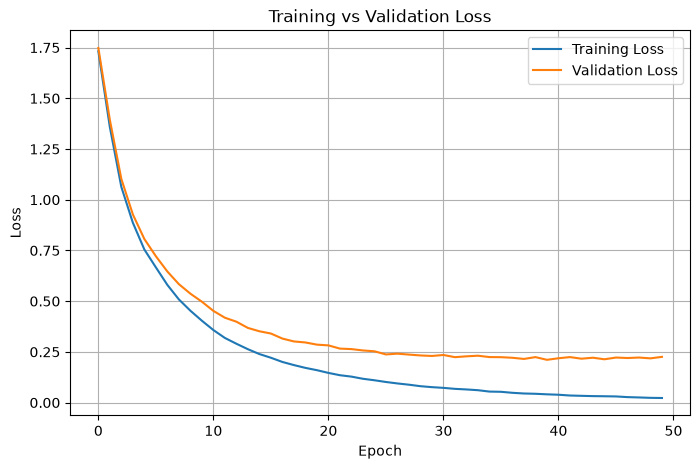

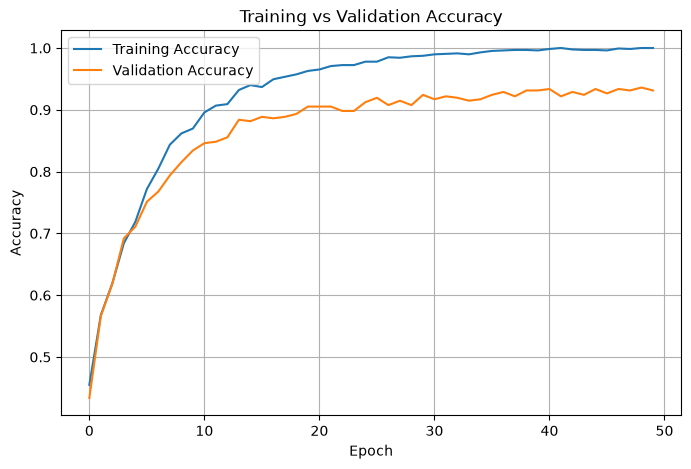

In [109]:
# TODO: 
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0

for epoch in range(50):
    model.train()

    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()
        optimizer.step()

    model.eval()

    with torch.no_grad():
        train_loss = 0
        train_correct = 0
        train_total = 0
        val_loss = 0
        val_correct = 0
        val_total = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            train_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)
            train_correct += (predictions == yb).sum().item()
            train_total += yb.size(0)

        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)
            val_correct += (predictions == yb).sum().item()
            val_total += yb.size(0)

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        train_accuracy = train_correct / train_total
        val_accuracy = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "ffn_best.pt")

    print(
        f"Epoch {epoch+1}/50 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()





**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** 
* 1
The forward pass is performed when the model predicts the outputs:
$$
logits = model(xb)
$$

$$
loss = criterion(logits, yb)
$$

This is equivalent to the forward propagation step in the NumPy implementation, where the network computes predictions and then calculates the loss.

The gradients are computed by:

$$
loss.backward()
$$

This is equivalent to manually calculating the gradients during backpropagation in the NumPy implementation.

The parameter update rule is:

$$
optimizer.step()
$$

This corresponds to updating the model's weights and biases using the computed gradients, similar to subtracting the learning rate multiplied by the gradients in the NumPy implementation.

* 2
The model shows slight overfitting. By the end of training, the training accuracy reaches almost 100% while the validation accuracy levels off at about 93%. Similarly, the training loss continues to decrease to approximately 0.02, whereas the validation loss stops improving and stabilizes around 0.22. The gap between the training and validation performance indicates that the model learns the training data extremely well but does not generalize quite as well to unseen data. However, because the validation accuracy remains high and the validation loss does not increase sharply, the overfitting is only mild.

* 3
optimizer.zero_grad() clears the gradients from the previous batch before computing new ones. PyTorch accumulates gradients by default, so if this function is not called, gradients from previous batches are added to the current gradients. This results in incorrect parameter updates, causing unstable training and preventing the model from learning properly.



### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [110]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [111]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.